<h1 align="center">ใบงานที่ 3 Regression & Classification</h1>

## LAB 1: Regression 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('Dataset.csv')

df_reg = df.dropna(subset=['Bounty']).copy()

print("Number of available rows for regression:", len(df_reg))
display(df_reg.head())

Number of available rows for regression: 32


,Character,Crew,Bounty,Devil_Fruit,Devil_Fruit_Type,Height_cm,Age,Origin_Sea,Status
0,Monkey D. Luffy,Straw Hat Pirates,3.000000e+09,Hito Hito no Mi Model: Nika,Mythical Zoan,174,19,East Blue,Alive
1,Portgas D. Ace,Whitebeard Pirates,5.500000e+08,Mera Mera no Mi,Logia,185,20,South Blue,Deceased
3,Roronoa Zoro,Straw Hat Pirates,1.111000e+09,NaN,NaN,181,21,East Blue,Alive
4,Nami,Straw Hat Pirates,3.660000e+08,NaN,NaN,170,20,East Blue,Alive
5,Usopp,Straw Hat Pirates,5.000000e+08,NaN,NaN,176,19,East Blue,Alive


<div style="padding: 12px; background-color: #0f1c20; border-left: 5px solid #ff0000; border-radius: 4px; color: #00ff88;">
  <strong> Note:</strong> Load dataset from CSV (Dataset_One Piece)
</div>

### Simple Linear Regression

=== Simple Linear Regression Results ===
Slope (B1 / Coefficient): 74,973,784.47
Intercept (B0): -742,977,055.23
Linear Equation: Bounty = -742,977,055.23 + (74,973,784.47 * Age)
--------------------------------------------------
R² Score: -2.5683
MAE: 2,282,468,036.47 Berries
RMSE: 2,694,637,466.93 Berries


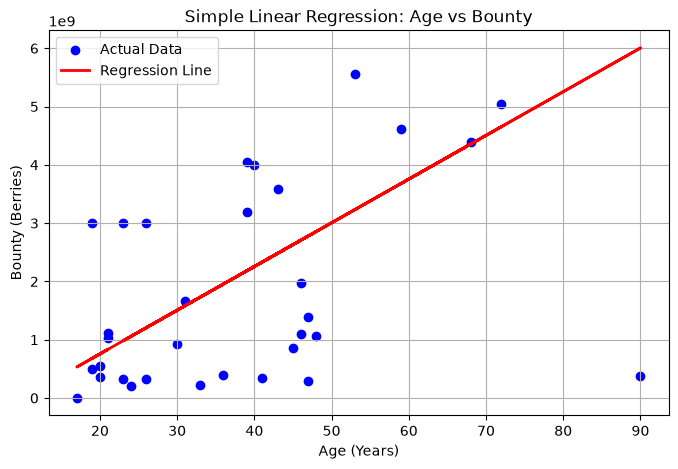

In [12]:
# 1. Define Feature (X) and Target (y)
X_simple = df_reg[['Age']]
y_simple = df_reg['Bounty']

# 2. Split data into Training Set (80%) and Testing Set (20%)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# 3. Initialize and train the Simple Linear Regression model
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# 4. Make predictions on the test set
y_pred_s = model_simple.predict(X_test_s)

# 5. Display equation and performance metrics
print("=== Simple Linear Regression Results ===")
print(f"Slope (B1 / Coefficient): {model_simple.coef_[0]:,.2f}")
print(f"Intercept (B0): {model_simple.intercept_:,.2f}")
print(f"Linear Equation: Bounty = {model_simple.intercept_:,.2f} + ({model_simple.coef_[0]:,.2f} * Age)")
print("-" * 50)
print(f"R² Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f"MAE: {mean_absolute_error(y_test_s, y_pred_s):,.2f} Berries")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_s)):,.2f} Berries")

# 6. Plot actual data points vs Regression line
plt.figure(figsize=(8, 5))
plt.scatter(df_reg['Age'], df_reg['Bounty'], color='blue', label='Actual Data')
plt.plot(df_reg['Age'], model_simple.predict(df_reg[['Age']]), color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Age vs Bounty')
plt.xlabel('Age (Years)')
plt.ylabel('Bounty (Berries)')
plt.legend()
plt.grid(True)
plt.show()

### Multiple Linear Regression

In [13]:
# 1. Select features and handle missing values in Devil_Fruit_Type
df_multi = df_reg[['Age', 'Height_cm', 'Devil_Fruit_Type', 'Bounty']].copy()
df_multi['Devil_Fruit_Type'] = df_multi['Devil_Fruit_Type'].fillna('None')

# 2. Apply One-Hot Encoding to categorical feature
df_multi_encoded = pd.get_dummies(df_multi, columns=['Devil_Fruit_Type'], drop_first=True)

# 3. Define Features (X) and Target (y)
X_multi = df_multi_encoded.drop(columns=['Bounty'])
y_multi = df_multi_encoded['Bounty']

# 4. Split data into Training Set (80%) and Testing Set (20%)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# 5. Initialize and train the Multiple Linear Regression model
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# 6. Make predictions on the test set
y_pred_m = model_multi.predict(X_test_m)

# 7. Display evaluation metrics
print("=== Multiple Linear Regression Results ===")
print(f"R² Score: {r2_score(y_test_m, y_pred_m):.4f}")
print(f"MAE: {mean_absolute_error(y_test_m, y_pred_m):,.2f} Berries")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_m)):,.2f} Berries")

# 8. Display Feature Coefficients
print("\n=== Feature Coefficients ===")
coeff_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
})
display(coeff_df)

=== Multiple Linear Regression Results ===
R² Score: -2.2752
MAE: 2,213,890,494.58 Berries
RMSE: 2,581,589,244.23 Berries

=== Feature Coefficients ===


,Feature,Coefficient
0,Age,9.449225e+07
1,Height_cm,-1.517238e+06
2,Devil_Fruit_Type_Logia,1.558999e+09
3,Devil_Fruit_Type_Mythical Zoan,3.122870e+09
4,Devil_Fruit_Type_None,1.537261e+09
5,Devil_Fruit_Type_Paramecia,1.275098e+09
6,Devil_Fruit_Type_Special Paramecia,-3.744556e+08
7,Devil_Fruit_Type_Zoan,8.620826e+08
8,Devil_Fruit_Type_paramecia,0.000000e+00


### Bounty Prediction System

In [17]:
# 1. Prepare features (Age & Height_cm) and target (Bounty)
X_sys = df_reg[['Age', 'Height_cm']]
y_sys = df_reg['Bounty']

# 2. Train-Test Split (80:20)
X_train_sys, X_test_sys, y_train_sys, y_test_sys = train_test_split(
    X_sys, y_sys, test_size=0.2, random_state=42
)

# 3. Model training
bounty_system = LinearRegression()
bounty_system.fit(X_train_sys, y_train_sys)

# 4. Model Evaluation
y_pred_sys = bounty_system.predict(X_test_sys)

print("=== Bounty Prediction System Results ===")
print(f"Age Coefficient: {bounty_system.coef_[0]:,.2f}")
print(f"Height_cm Coefficient: {bounty_system.coef_[1]:,.2f}")
print(f"Intercept: {bounty_system.intercept_:,.2f}")
print("-" * 50)
print(f"R² Score: {r2_score(y_test_sys, y_pred_sys):.4f}")
print(f"MAE: {mean_absolute_error(y_test_sys, y_pred_sys):,.2f} Berries")

# 5. Inference / Prediction on new character data
# You can change the values in this DataFrame freely!
input_age = 30
input_height = 314
new_character = pd.DataFrame({'Age': [input_age], 'Height_cm': [input_height]})
predicted_bounty = bounty_system.predict(new_character)

print("-" * 50)
print(f"🔮 Predicted Bounty for new character (Age={new_character['Age'].iloc[0]}, Height={new_character['Height_cm'].iloc[0]}cm): {predicted_bounty[0]:,.2f} Berries")

=== Bounty Prediction System Results ===
Age Coefficient: 92,891,976.18
Height_cm Coefficient: -1,661,830.75
Intercept: -884,187,911.96
--------------------------------------------------
R² Score: -3.3008
MAE: 2,364,157,609.74 Berries
--------------------------------------------------
🔮 Predicted Bounty for new character (Age=30, Height=314cm): 1,380,756,516.99 Berries
